# Übung 6

**Gruppenname:**

*ESM*

Gehen Sie wie folgt vor:

1. Kopieren Sie jetzt dieses Jupyter Notebook in Ihren Ordner (`Abgaben/Team_WXYZ`)

2. Tragen Sie Ihren Gruppennamen auch ganz oben bei "Name Ihrer Gruppe" ein.

3. Bearbeiten Sie dann dieses Notebook. Falls Sie das Notebook im Browser bearbeiten, vergessen Sie nicht, es regelmäßig zu speichern (z.B. über `Strg + S` oder über `File -> Save and Checkpoint`).

### In dieser Übung ...

... werden wir intensiv mit Dimensionsreduktion mittels Hauptkomponentenzerlegung (PCA) beschäftigen. Wir werden die PCA implementieren und damit verschiedene Datensätze untersuchen.

### 6.1 Eigengesichter (Bildkompression mittels PCA)

In den 90er Jahren haben Forscher des Olivetti Research Laboratory in Cambridge, basierend auf der PCA, eines der frühen Verfahren für Gesichtserkennung entwickelt. Das Olivetti Research Laboratory wurde später von AT&T übernommen, und der [Datensatz](https://web.archive.org/web/20051104013331/http://www.cl.cam.ac.uk/research/dtg/attarchive/facedatabase.html), auf dem die Arbeiten beruhten, wurde unter dem Namen *Olivetti Faces Dataset* bekannt.

Wir werden uns in dieser Übung mit dem Aspekt der Dimensionsreduktion mithilfe von PCA beschäftigen, und wie sie zur Datenkompression von Gesichtsbildern eingesetzt werden kann. Die PCA-Richtungen (Hauptkomponenten) eines Datensatzes von Gesichtsbildern werden auch *Eigengesichter* bzw. *Eigenfaces* genannt.

**Ihre Daten**

Die Olivetti Faces bestehen aus 400 Graustufenbildern (64x64 Pixel), die von 40 Personen stammen. Von jeder Person wurden 10 Gesichtsbilder angefertigt, wobei die Personen gebeten wurden, unterschiedliche Gesichtsausdrücke zu zeigen. Gleichzeitig wurde die Beleuchtung während der Fotoaufnahmen variiert.

Der Datensatz kann über scikit-learn direkt importiert werden.

* Importieren Sie den Datensatz durch das Ausführen der untenstehenden Code-Zelle.

In [31]:
import numpy as np
from matplotlib import pyplot as plt
from sklearn.datasets import fetch_olivetti_faces

# Import data
data, targets = fetch_olivetti_faces(return_X_y=True)

**Ihre Aufgaben**

* Bei der Implementierung der PCA in den nachfolgenden Teilaufgaben nutzen Sie bitte ausschließlich *Numpy* und keine Funktionen von sklearn.

(1) Untersuchen Sie die Daten in `data`: 

* Nennen Sie die Anzahl der Samples (Gesichter) in diesem Datensatz. 400
* Nennen Sie die Anzahl der Features (Merkmale, Pixel) jedes Gesichts. 4096
* Prüfen Sie, in welchem Wertebereich die Pixelwerte variieren und nennen Sie den Wertebereich.

In [32]:
targets = np.array(targets)
data = np.array(data)

print(data)
print("\n")
print(targets)

n_samples, m_fetaures = data.shape

print(f"n_samples: {n_samples}")
print(f"m_features: {m_fetaures}")
print(f"Min Pixel Value: {np.min(data)}")
print(f"Max Pixel Value: {np.max(data)}")


[[0.30991736 0.3677686  0.41735536 ... 0.15289256 0.16115703 0.1570248 ]
 [0.45454547 0.47107437 0.5123967  ... 0.15289256 0.15289256 0.15289256]
 [0.3181818  0.40082645 0.49173555 ... 0.14049587 0.14876033 0.15289256]
 ...
 [0.5        0.53305787 0.607438   ... 0.17768595 0.14876033 0.19008264]
 [0.21487603 0.21900827 0.21900827 ... 0.57438016 0.59090906 0.60330576]
 [0.5165289  0.46280992 0.28099173 ... 0.35950413 0.3553719  0.38429752]]


[ 0  0  0  0  0  0  0  0  0  0  1  1  1  1  1  1  1  1  1  1  2  2  2  2
  2  2  2  2  2  2  3  3  3  3  3  3  3  3  3  3  4  4  4  4  4  4  4  4
  4  4  5  5  5  5  5  5  5  5  5  5  6  6  6  6  6  6  6  6  6  6  7  7
  7  7  7  7  7  7  7  7  8  8  8  8  8  8  8  8  8  8  9  9  9  9  9  9
  9  9  9  9 10 10 10 10 10 10 10 10 10 10 11 11 11 11 11 11 11 11 11 11
 12 12 12 12 12 12 12 12 12 12 13 13 13 13 13 13 13 13 13 13 14 14 14 14
 14 14 14 14 14 14 15 15 15 15 15 15 15 15 15 15 16 16 16 16 16 16 16 16
 16 16 17 17 17 17 17 17 17 17 17 17 18 18 

(2) Nutzen Sie Ihre Erkenntnisse aus (1) und visualisieren Sie das Gesicht 296 (0-basierte Zählung).

* Dabei kann Ihnen [dieser Befehl](https://numpy.org/doc/stable/reference/generated/numpy.ndarray.reshape.html?highlight=reshape#numpy.ndarray.reshape) und [jener Befehl](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.imshow.html) hilfreich sein. Wenn Sie `cmap=gray` verwenden, dann wird das Gesicht in Graustufen dargestellt.

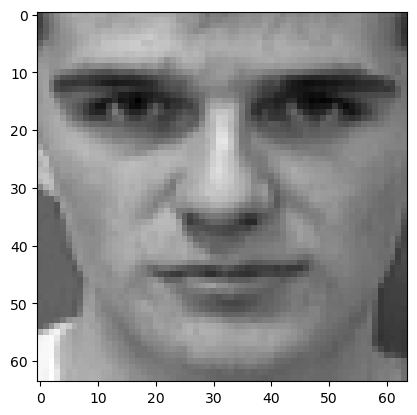

In [3]:
import matplotlib.pyplot as plt

plt.imshow(np.reshape(data[296], (64, 64)),cmap="gray")

(3) Visualisieren Sie in einem [3x3 Plot](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.subplot.html) die Gesichter 291 bis 299.

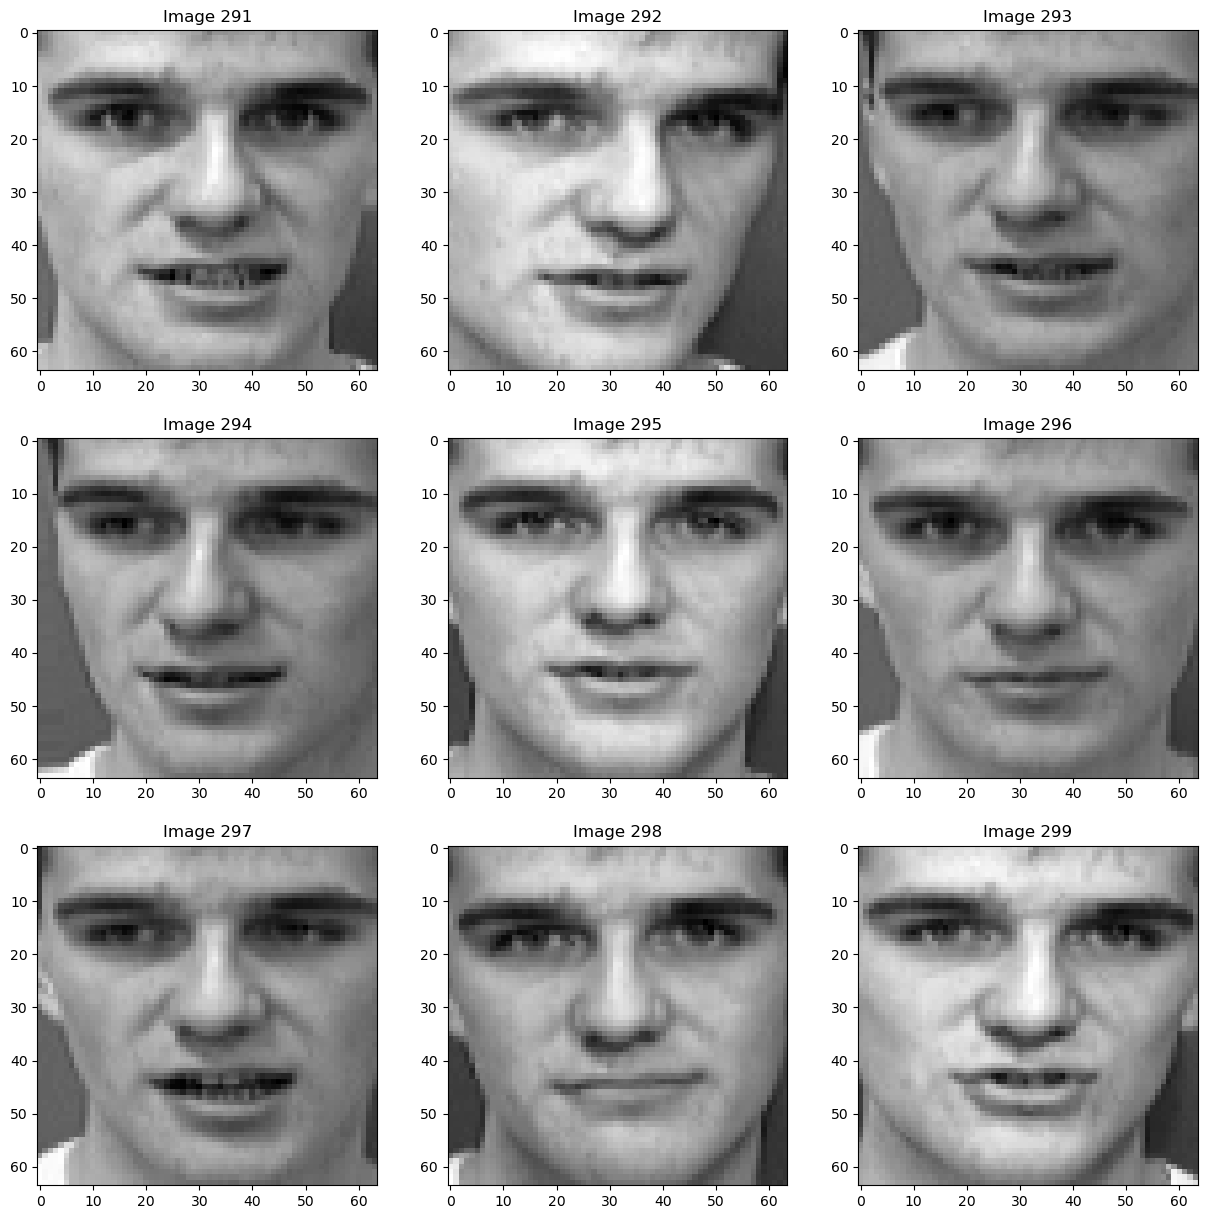

In [4]:
fig, ax = plt.subplots(3, 3, figsize=(15,15))

i = 0
j = 0
for idx in range(291, 300):
    ax[i, j].imshow(np.reshape(data[idx], (64, 64)), cmap="grey")
    ax[i, j].set_title(f"Image {idx}")
    j = (j + 1) % 3
    i = i + 1 if j == 0 else i





(4) Nehmen Sie die Folien zur heutigen Vorlesung zur Hand und schlagen Sie nach, wie die PCA definiert ist.

* Überlegen Sie sich die Dimensionen der Kovarianzmatrix des Datensatzes und nennen Sie sie hier.

Die Dimension sei 400 x 4096

(5) Bestimmen Sie die [Kovarianzmatrix](https://numpy.org/doc/stable/reference/generated/numpy.cov.html) `cov_mat` des Datensatzes. Überprüfen Sie, ob die Dimensionen der Kovarianz mit Ihrer Erwartung aus Schritt (4) übereinstimmt.

* Hinweis: Eine typische Fehlerquelle besteht bei diesem Schritt darin, dass die Kovarianzmatrix nicht korrekt berechnet wird. Es ist daher wichtig, dass Sie wissen und überprüfen, ob die Dimensionen der Kovarianzmatrix stimmen.

In [33]:
cov_mat = np.cov(data.T)
cov_mat.shape

(4096, 4096)

(6) [Bestimmen](https://numpy.org/doc/stable/reference/generated/numpy.linalg.eigh.html) Sie nun die Eigenwerte `eig_vals` und Eigenvektoren `eig_vecs` Ihrer Kovarianzmatrix.

In [42]:
eig_vals, eig_vecs = np.linalg.eigh(cov_mat)
eig_vals


array([-2.95150403e-15, -2.39417786e-15, -2.26961041e-15, ...,
        6.30461472e+00,  1.10717621e+01,  1.88401758e+01], shape=(4096,))

(7) Ein typischer Fehler ist es, anzunehmen, dass Ihre Eigenwerte sortiert vorliegen. Dies ist im Allgemeinen *nicht* der Fall. Daher sortieren Sie die Eigenwerte in absteigender Größe. Nutzen Sie dafür [np.argsort()](https://docs.scipy.org/doc/numpy/reference/generated/numpy.argsort.html), um die Sortierung in eine separate Variable `idx` zu speichern, mit der Sie dann die Sortierung der Eigenwerte vornehmen.

* Beachten Sie, dass `np.argsort()` in aufsteigender Reihenfolge sortiert. Sortieren Sie also zunächst aufsteigend und kehren Sie dann die Reihenfolge im resultierenden Array um. 

In [43]:
idx = np.argsort(eig_vals)[::-1]
eig_vals_sorted = eig_vals[idx]
eig_vecs_sorted = eig_vecs[:, idx.tolist()]


(8) Sortieren Sie nun die assoziierten Eigenvektoren, die Sie im Array `eig_vecs` gespeichert hatten.
* Beachten Sie: Die Eigenvektoren liegen als Spalten in `eigen_vecs` vor, *nicht* als Zeilen. Dies können Sie auch in der [Dokumentation](https://docs.scipy.org/doc/numpy/reference/generated/numpy.linalg.eig.html) nachlesen. Das Verwechseln von Zeilen und Spalten ist eine typische Fehlerquelle.
* Nutzen Sie `idx`, um die Spalten (also die Eigenvektoren) so zu sortieren, dass sie zu Ihren sortierten Eigenwerten passen. Dazu können Sie [Integer Array Indexing](https://numpy.org/doc/stable/user/basics.indexing.html#integer-array-indexing) einsetzen. Für Integer Array Indexing müssen Sie Ihr Array `idx` [in eine Python Liste umwandeln](https://docs.scipy.org/doc/numpy/reference/generated/numpy.ndarray.tolist.html).

Bestimmen Sie den Anteil der erklärten Varianz (*Proportion of Variance Explained*, PVE) als Funktion der Anzahl der Komponenten und visualisieren Sie sie. Visualisieren Sie ebenfalls die kumulative PVE als Funktion der Komponentenanzahl.

* Beschreiben Sie kurz den Verlauf der PVE in Ihren beiden Abbildungen. Wie interpretieren Sie diesen Verlauf? (1-2 Sätze)



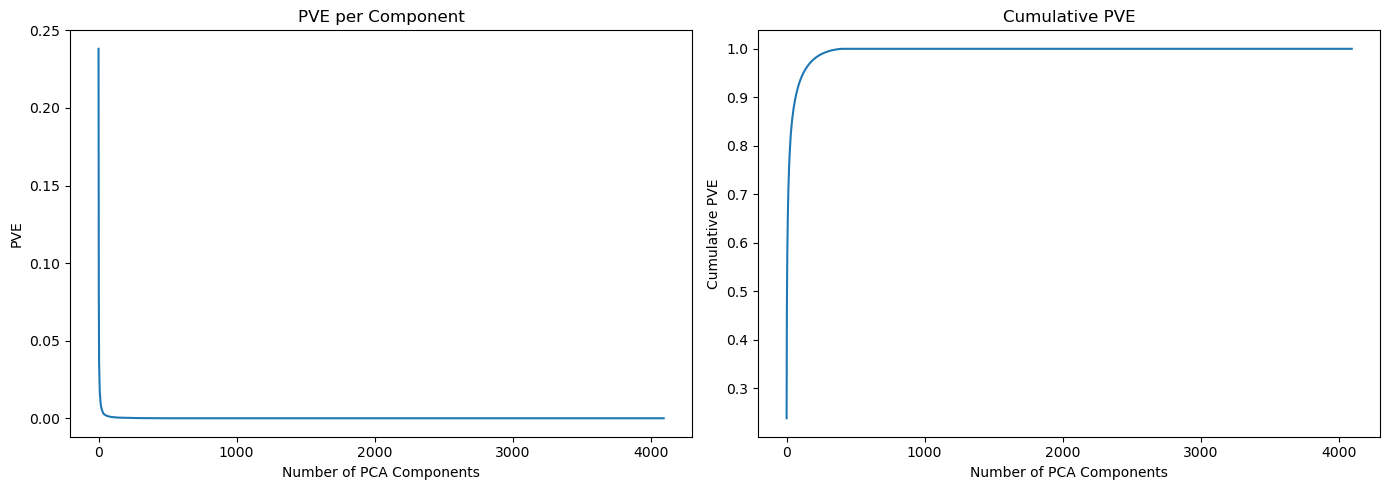

In [44]:
pve = eig_vals_sorted / np.sum(eig_vals_sorted)
cumulative_pve = np.cumsum(pve)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].plot(pve)
ax[0].set_xlabel("Number of PCA Components")
ax[0].set_ylabel("PVE")
ax[0].set_title("PVE per Component")

ax[1].plot(cumulative_pve)
ax[1].set_xlabel("Number of PCA Components")
ax[1].set_ylabel("Cumulative PVE")
ax[1].set_title("Cumulative PVE")

plt.tight_layout()
plt.show()


(10) Wir untersuchen nun die Hauptkomponenten der PCA.

* Visualisieren Sie das erste Eigengesicht (*eigenface*). Dies entspricht der 1. PCA-Komponente, also dem Eigenvektor der Kovarianzmatrix, der dem größten Eigenwert zugeordnet ist. Dieser Eigenvektor wird auch als "erster Eigenvektor" bezeichnet.

* Visualisieren Sie ebenfalls die Eigengesichter 2 bis 5.

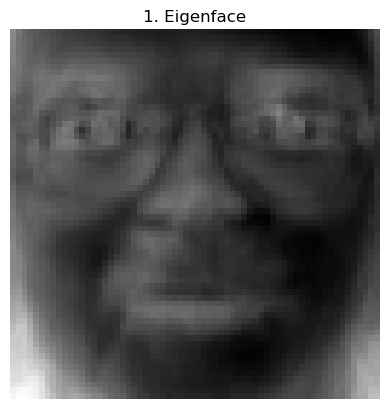

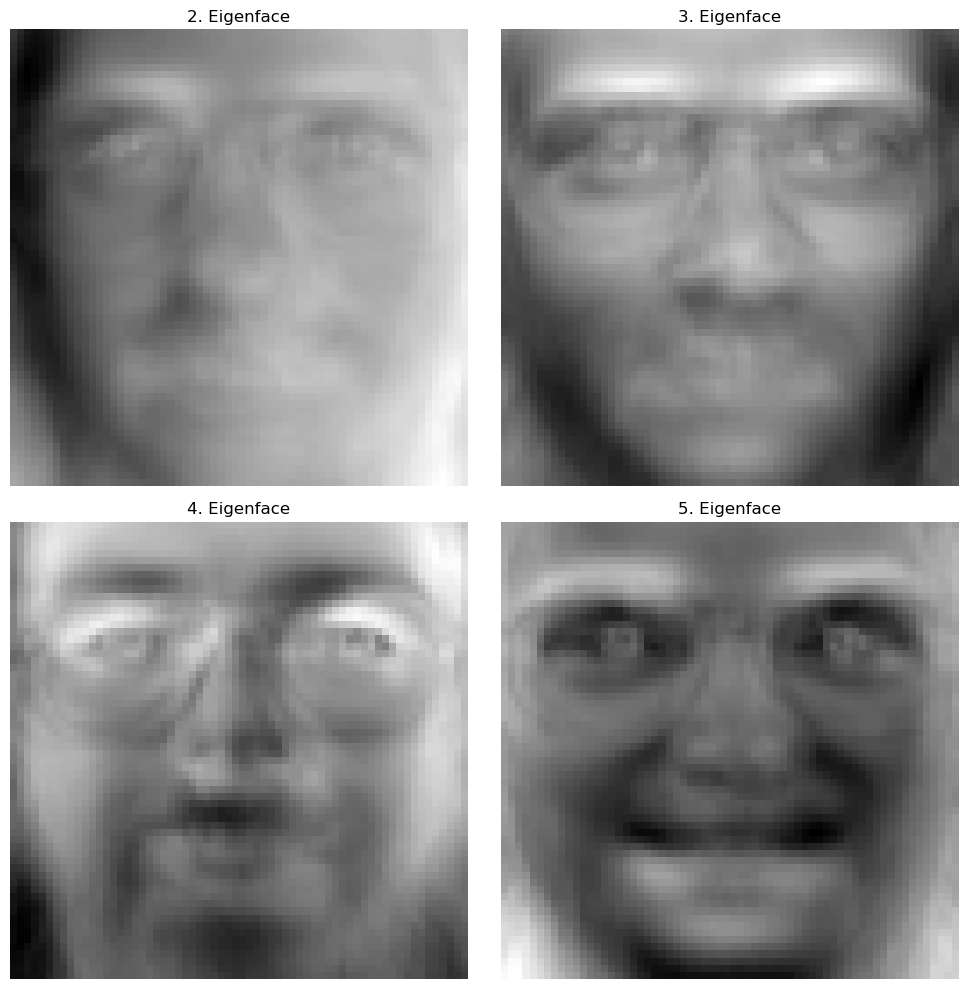

In [45]:
plt.imshow(eig_vecs_sorted[:, 0].reshape(64, 64), cmap="gray")
plt.title("1. Eigenface")
plt.axis("off")
plt.show()

fig, ax = plt.subplots(2, 2, figsize=(10, 10))

i = 0
j = 0
for k in range(1, 5):
    ax[i, j].imshow(eig_vecs_sorted[:, k].reshape(64, 64), cmap="gray")
    ax[i, j].set_title(f"{k+1}. Eigenface")
    ax[i, j].axis("off")
    j = (j + 1) % 2
    i = i + 1 if j == 0 else i

plt.tight_layout()
plt.show()


(11) Die PCA-Komponenten (Eigengesichter) stellen eine Basis dar, mit der sich die Gesichter im Olivetti-Datensatz darstellen lassen. Ihre Erkenntnisse aus Teilaufgabe (9) deuten darauf hin, dass zur Darstellung der Gesichter nicht alle Basisvektoren notwendig sein werden. Dies werden Sie hier untersuchen.

Seien $f_1, \ldots, f_k$ die PCA-Komponenten der $k$-größten Eigenwerte, und bezeichne ${g}$ den Vektor, der das Gesicht 296 (0-basierte Zählung) darstellt. Projizieren Sie das Gesicht ${g}$ auf die ersten 25 PCA-Komponenten (Eigengesichter). Sie erhalten dadurch 25 Koeffizienten $c_i$,

$$c_i = {f}_i^\text{T}({g}-{m}),$$

wobei $\vec{m}$ der Vektor der Mittelwerte über die Merkmale des gesamten Datensatzes ist. Denn: Vergessen Sie nicht, dass Sie Ihre Daten *vor* der Projektion zentrieren müssen. Dies bedeutet, dass Sie von den Merkmalen (Pixeln) des Gesichts 296 jeweils die Mittelwerte (ermittelt über den ganzen Datensatz) abziehen müssen.
  
Bemerkung:

* Sie haben hier das Gesicht 296 mithilfe von 25 Koeffizienten beschrieben und damit mit einem Vektor in einem 25-dimensionalen Raum. Dieser Raum ist deutlich kleiner als der ursprüngliche Raum (Dimensionsreduktion!). 

In [46]:
m = data.mean(axis=0)

new_face = eig_vecs_sorted[:, :25].T @ (data[296] - m)
new_face


array([ 4.51126537,  0.33240638, -1.25911962, -3.10278825,  2.47713771,
       -0.94908409,  0.72662085,  0.67298794, -0.67021554,  0.13549017,
        0.97646282, -1.29930461,  0.71614873,  0.89751506,  0.10672766,
        0.20047476, -0.03711112, -0.17506567, -0.47688135, -0.47038176,
       -0.31277987, -0.30728637,  0.72369202,  0.08072031,  0.1438456 ])

(12) Sie haben aus Teilaufgabe (11) 25 Koffizienten vorliegen, mit denen Sie - mithilfe der Eigengesichter - nun das Gesicht rekonstruieren werden. Rekonstruieren Sie das Gesicht aus den 25 Koeffizienten mithilfe der Eigengesichter,

$${g}^\prime = \left(\sum\limits_{i=1}^k c_i {f}_k\right) + {m},$$

wobei Sie auch hier sich daran erinnern, dass Sie für die Rekonstruktion nun den Mittelwertsvektor ${m}$, den Sie in Teilschritt (11) abgezogen hatten, wieder aufaddieren müssen.

* Visualisieren Sie in einem Plot das ursprüngliche Gesicht (links) sowie das rekonstruierte Gesicht (rechts).

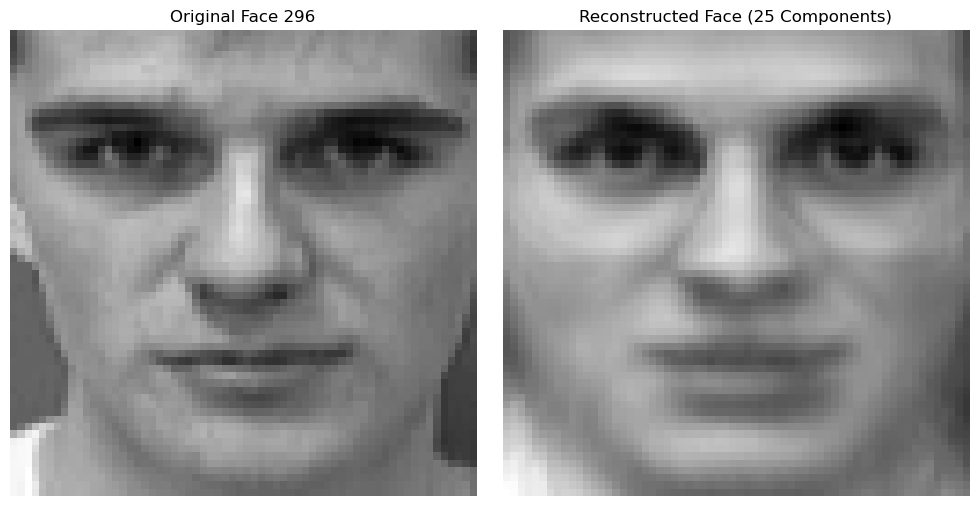

In [47]:
m = data.mean(axis=0)
reconstructed = new_face @ eig_vecs_sorted[:, :25].T + m

fig, ax = plt.subplots(1, 2, figsize=(10, 5))

ax[0].imshow(data[296].reshape(64, 64), cmap="gray")
ax[0].set_title("Original Face 296")
ax[0].axis("off")

ax[1].imshow(reconstructed.reshape(64, 64), cmap="gray")
ax[1].set_title("Reconstructed Face (25 Components)")
ax[1].axis("off")

plt.tight_layout()
plt.show()


(13) Experimentieren Sie mit einer größeren Anzahl von PCA-Komponenten und untersuchen Sie, wie sich die Projektion und die Rekonstruktion verbessert, wenn Sie die ersten 100 oder 200 PCA-Komponenten benutzen.

* Was beobachten Sie, wenn Sie die Anzahl der PCA-Komponenten erhöhen? (1-2 Sätze)

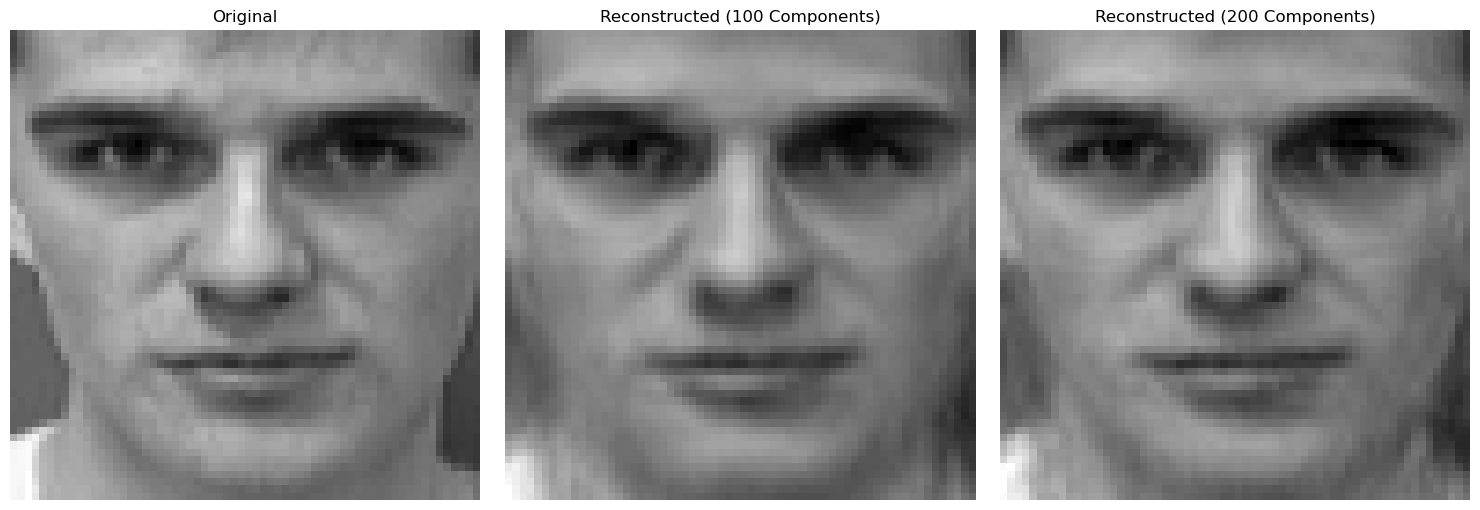

In [41]:
m = data.mean(axis=0)
g = data[296] - m

fig, ax = plt.subplots(1, 3, figsize=(15, 5))

ax[0].imshow(data[296].reshape(64, 64), cmap="gray")
ax[0].set_title("Original")
ax[0].axis("off")

for i, n_components in enumerate([100, 200]):
    coefficients = eig_vecs_sorted[:, :n_components].T @ g
    reconstructed = coefficients @ eig_vecs_sorted[:, :n_components].T + m
    ax[i + 1].imshow(reconstructed.reshape(64, 64), cmap="gray")
    ax[i + 1].set_title(f"Reconstructed ({n_components} Components)")
    ax[i + 1].axis("off")

plt.tight_layout()
plt.show()


(14) Nehmen Sie an, wir würden PCA als Bildkompressionsmethode einsetzen. Überdenken Sie folgendes Gedankenexperiment: Wir projizieren jedes Gesicht auf die 200 größten PCA-Komponenten (Eigengesichter) und erhalten jeweils 200 Koeffizienten pro Gesicht. Wir speichern nun diese Koeffizienten sowie die 200 PCA-Komponentenvektoren in einer Datei ab.

* Wie groß (in Megabytes) ist der Originaldatensatz, wenn wir zur Speicherung jedes Pixels 8 Bytes nutzen?
* Wie groß (in Megabytes) wäre der projizierte Datensatz, der lediglich die 200 Eigengesichter, die 200 Koeffizienten pro Gesicht sowie den Mittelwertsvektor (${m}$) enthält? Wir nehmen auch in diesem Fall an, dass jedes Pixel und jeder Koeffizient 8 Bytes belegt.

(15) \[Optional\] Nutzen Sie [ipython Widgets](https://ipywidgets.readthedocs.io/en/latest/examples/Using%20Interact.html), um eine interaktive Visualisierung der Gesichter des Datensatzes sowie ihrer Rekonstruktion zu erstellen: Legen Sie zwei Slider an: Mit dem ersten Slider können sie die Nummer des zu visualisierenden Gesichtes im Datensatz einstellen. Mit dem zweiten Slider können Sie die Anzahl der PCA-Komponenten für die Projektion und anschließende Rekonstruktion einstellen. Das Widget soll das ursprüngliche Gesicht sowie das rekonstruierte Gesicht darstellen.

### 6.2 MNIST

In dieser Übung arbeiten wir mit dem MNIST-Datensatz, der Bilder von 70000 handgeschriebenen Ziffern der Größe 28 x 28 Pixel beinhaltet. Im maschinellen Lernen und der Bildverarbeitung ist der MNIST-Datensatz das Äquivalent zum "Hello, World" in der Programmierung.

**Ihre Daten**

Der Datensatz kann über scikit-learn direkt importiert werden.

- Importieren Sie den Datensatz durch das Ausführen der untenstehenden Code-Zelle.

In [ ]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', version=1)
X = mnist.data
y = mnist.target.astype(int)


0        5
1        0
2        4
3        1
4        9
        ..
69995    2
69996    3
69997    4
69998    5
69999    6
Name: class, Length: 70000, dtype: int64

(1) Geben Sie die shape von `X` und `y` aus. Wie passt die Größe mit der Größenangabe 28 x 28 Pixel zusammen?

In [53]:
print(f"Shape of X {X.shape}")
print(f"Shape of y {y.shape}")

# Jede Zeile ist ein 28 mal 28 Pixel großes Bild

Shape of X (70000, 784)
Shape of y (70000,)


(2) Ändern Sie die Form von `X` so, dass die letzten beiden Achsen die Höhe und Breite der Bilder angeben.

In [ ]:
X_new = np.array(X).reshape((70000, 28, 28))

(70000, 28, 28)

(3) Filtern Sie mithilfe von `y` als Bilder aus `X`, die eine $2$ enthalten.

In [60]:
X_filtered = X_new[[idx for idx, label in enumerate(y) if label != 2]]

X_filtered.shape

(63010, 28, 28)

(4) Visualisieren Sie die ersten 9 Ziffern des Datensatzes. Nutzen Sie dafür [plt.subplots](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.subplots.html). Visualisieren Sie die Ziffern in Graustufen (`cmap='gray'`) und blenden Sie x- und y-Ticks aus (`ax.axis('off')`).

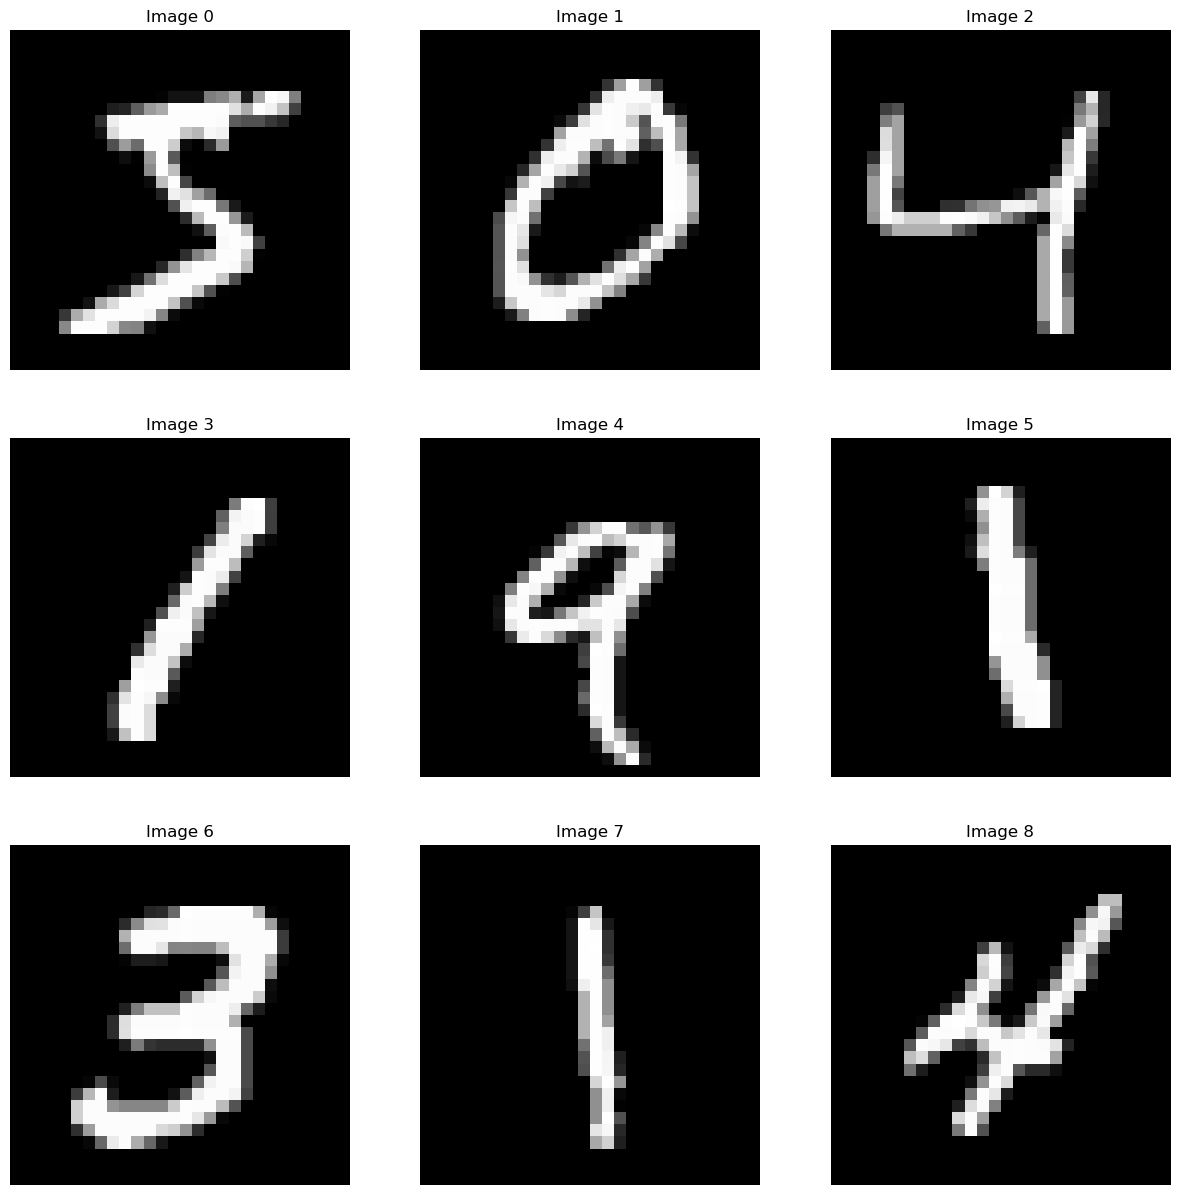

In [61]:
fig, ax = plt.subplots(3, 3, figsize=(15, 15))

i = 0 
j = 0 

for n in  range(9):
    ax[i, j].imshow(X_filtered[n], cmap="gray")
    ax[i, j].set_title(f"Image {n}")
    ax[i, j].axis("off")
    j = (j + 1) % 3
    i = i + 1 if j == 0 else i

(5) Berechnen und visualisieren Sie den Mittelwert aller $2$-Bilder.

**Hinweis:** Achten Sie darauf, dass Sie den Mittelwert für jede Dimension einzeln bestimmen, indem Sie den richtigen Wert für `axis` an [np.mean](https://numpy.org/doc/2.2/reference/generated/numpy.mean.html) übergeben.

In [ ]:
X_2 = np.array(X)[[idx for idx, label in enumerate(y) if label == 2]]


X_2_mean_vec = np.mean(X_2, axis=0)
X_2_mean_vec2 = np.mean(X_2, axis=1)

print(f"Mean shape across features: {X_2_mean_vec.shape}")
print(f"Mean shape across samples: {X_2_mean_vec2.shape}")


Mean shape across features: (784,)
Mean shape across samples: (6990,)


array([37.75637755, 31.42219388, 52.01658163, ..., 60.26530612,
       42.14795918, 49.45535714], shape=(6990,))

(6) Wenden Sie die PCA auf den Datensatz an und visualisieren die erklärte Varianz als Funktion der Anzahl der Komponenten.

**Hinweis:** Hierfür muss `X` wieder die ursprüngliche shape haben, d.h. die einzelnen Bilder müssen als Vektor, nicht als Matrix übergeben werden.

In [ ]:
X_s = X - np.mean(X, axis=0)


cov = np.cov(X_s.T)

eig_vals, eig_vecs = np.linalg.eigh(cov)

sorted_indices = np.argsort(eig_vals)[::-1]
eig_vals_sorted = eig_vals[sorted_indices]

sorted_eig_vecs = eig_vecs[:, sorted_indices]



(784,)

Text(0.5, 1.0, 'Cumulative PVE')

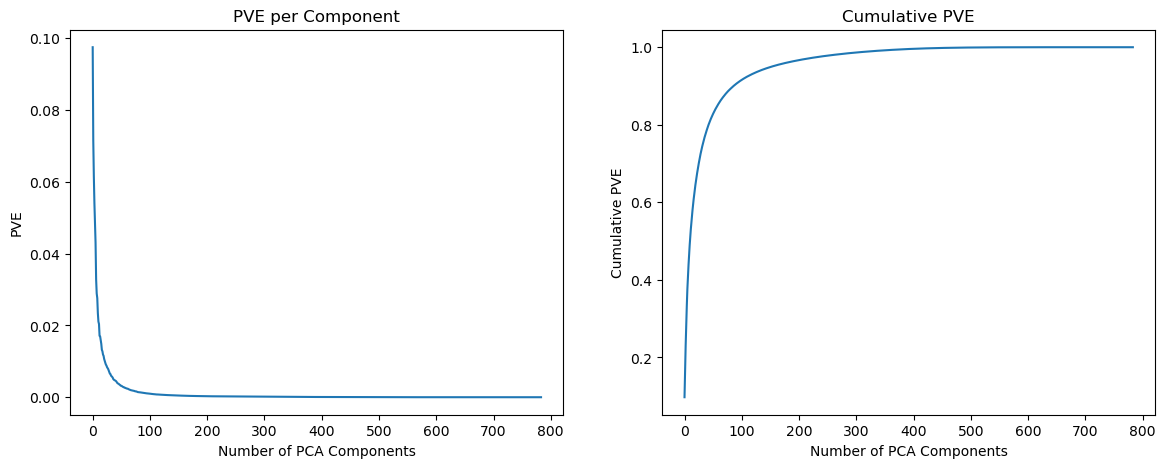

In [76]:
pve = eig_vals_sorted / np.sum(eig_vals_sorted)
cumulative_pve = np.cumsum(pve)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].plot(pve)
ax[0].set_xlabel("Number of PCA Components")
ax[0].set_ylabel("PVE")
ax[0].set_title("PVE per Component")

ax[1].plot(cumulative_pve)
ax[1].set_xlabel("Number of PCA Components")
ax[1].set_ylabel("Cumulative PVE")
ax[1].set_title("Cumulative PVE")



(7) Visualisieren Sie die ersten $4$ Hauptkomponenten (und versuchen diese zu interpretieren).

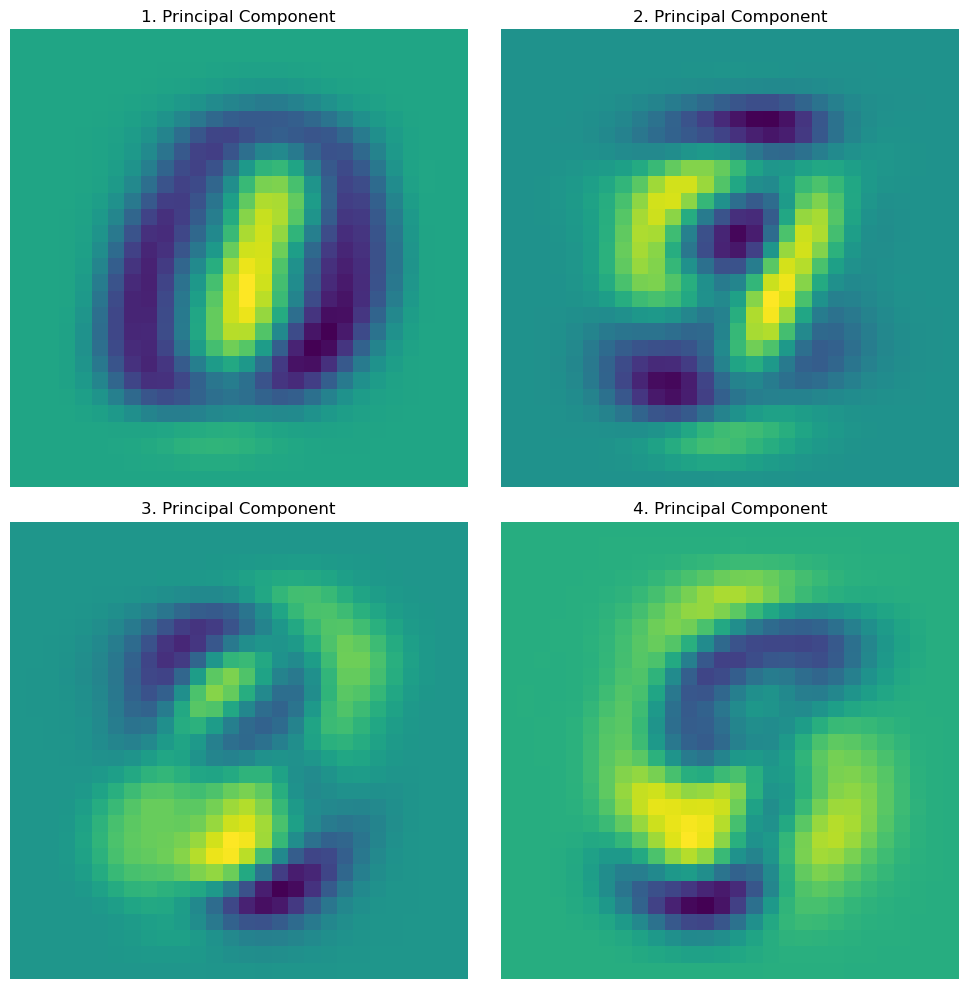

In [ ]:
fig, ax = plt.subplots(2, 2, figsize=(10, 10))

i = 0
j = 0
for k in range(4):
    ax[i, j].imshow(sorted_eig_vecs[:, k].reshape(28, 28))
    ax[i, j].set_title(f"{k+1}. Principal Component")
    ax[i, j].axis("off")
    j = (j + 1) % 2
    i = i + 1 if j == 0 else i

plt.tight_layout()
plt.show()


(8) Nutzen Sie die Hauptkomponenten, um neue Bilder zu generieren. 
- Erstellen Sie hierfür eine Stichprobe (im niedrigdimensionalen Raum) mit einer ähnlichen Verteilung wie die Projektionen der echten Bilder.
- Transformieren Sie anschließend die Stichprobe in den ursprünglichen (höherdimensionalen) Raum.

        model = PCA(n_components=4)
        X_proj = model.fit_transform(X)
        X_gen = (np.random.randn(20, 4) * np.std(X_proj, axis=0, keepdims=True)
                 + np.mean(X_proj, axis=0, keepdims=True))
        X_reconstructed = model.inverse_transform(X_gen)

In [113]:
n_components = 4
m_mnist = np.array(X.mean(axis=0))  

X_proj = np.array(X_s) @ sorted_eig_vecs[:, :n_components]  

X_gen = (np.random.randn(20, n_components)
         * np.std(X_proj, axis=0, keepdims=True)
         + np.mean(X_proj, axis=0, keepdims=True))  

X_reconstructed = X_gen @ sorted_eig_vecs[:, :n_components].T + m_mnist  

print(f"X_proj shape: {X_proj.shape}")
print(f"X_gen shape: {X_gen.shape}")
print(f"X_reconstructed shape: {X_reconstructed.shape}")


X_proj shape: (70000, 4)
X_gen shape: (20, 4)
X_reconstructed shape: (20, 784)


(9) Visualisieren Sie die neu erstellten Bilder.

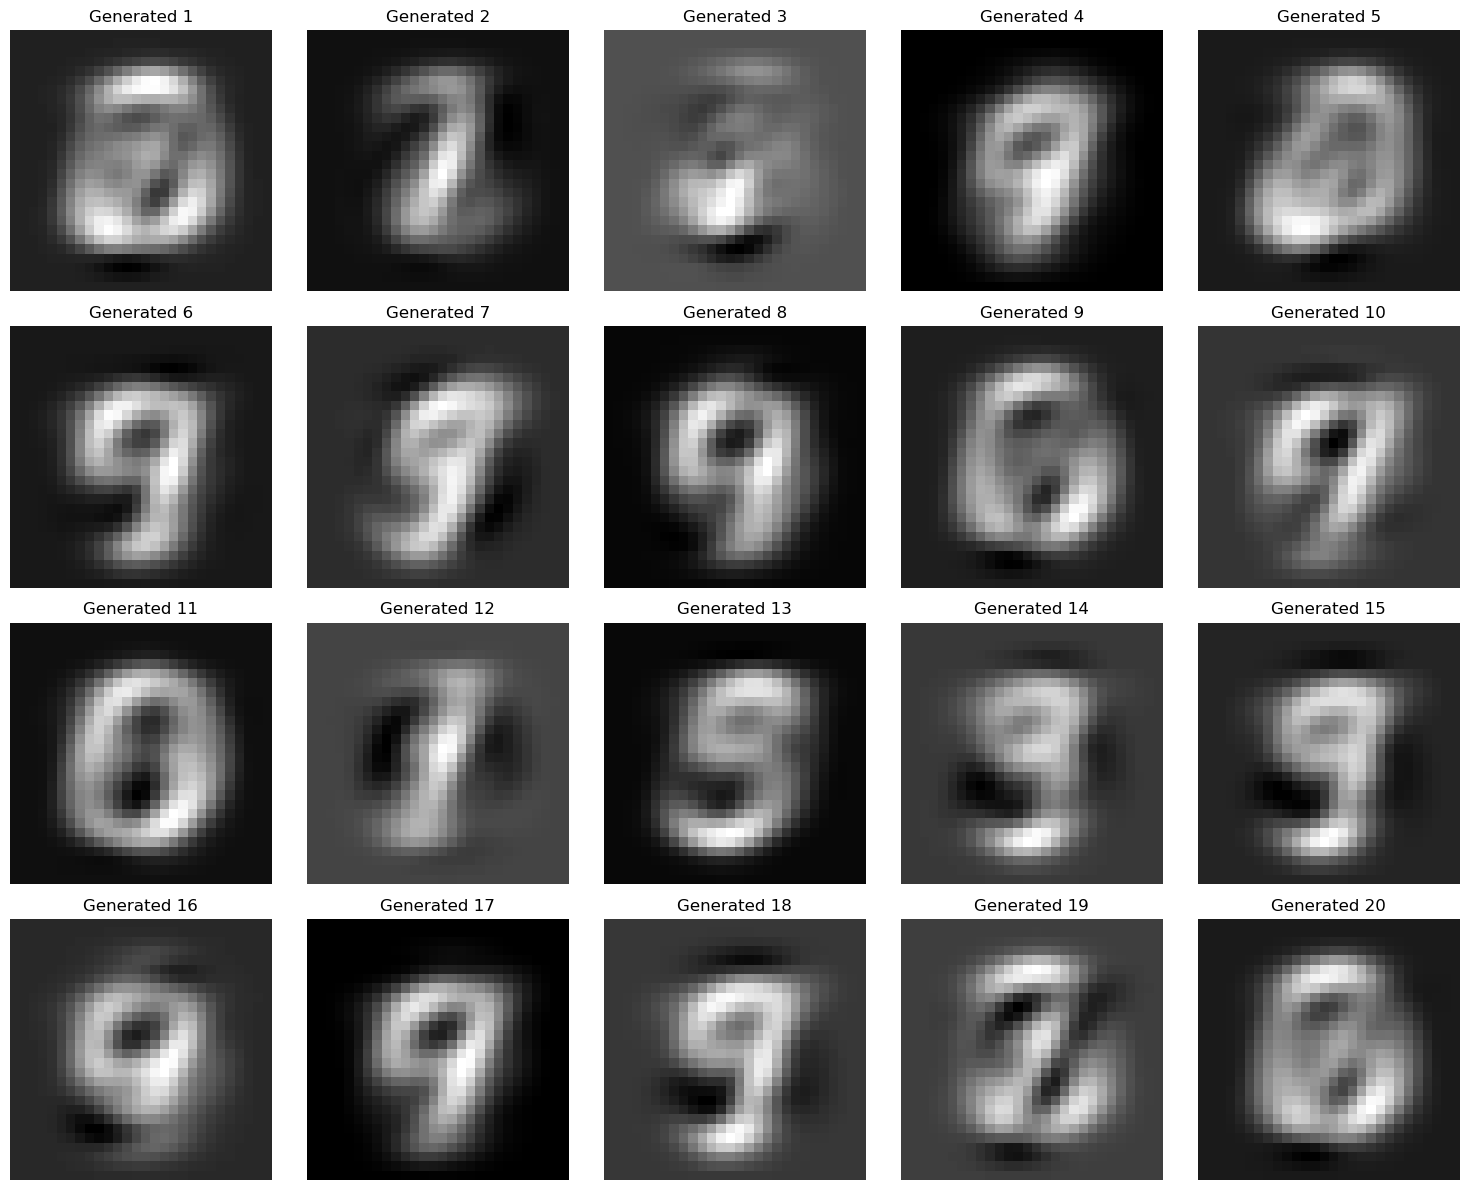

In [112]:
fig, ax = plt.subplots(4, 5, figsize=(15, 12))

for k in range(20):
    row, col = divmod(k, 5)
    ax[row, col].imshow(X_reconstructed[k].reshape(28, 28), cmap="gray")
    ax[row, col].set_title(f"Generated {k+1}")
    ax[row, col].axis("off")

plt.tight_layout()
plt.show()


(10) Sehen die erzeugten Bilder so aus wie Sie erwarten würden? Sehen sie so ähnlich aus wie die echten Bilder?

In [ ]:
# No

(11) [Optional] Optimieren Sie die Erzeugung künstlicher Ziffern, indem Sie die Anzahl der Komponenten und die "niedrigdimensionale Stichprobe" `X_gen` optimieren.

### 6.3 Standardisierung und PCA

In diesem Übungsteil werden wir uns noch einmal mit der PCA beschäftigen, allerdings dieses Mal auf konzeptioneller Ebene.

Die Kovarianzmatrix $S$ ist definiert als,

$$S = \frac{1}{N} \sum\limits_{n=1}^N (\mathbf{x}_n - \bar{\mathbf{x}}) (\mathbf{x}_n - \bar{\mathbf{x}})^T,$$

wobei $\mathbf{x}_n$ der Featurevektor des $n$-ten Datenpunktes und $\mathbf{\bar{x}}$ den Mittelwertsvektor über alle Datenpunkte bezeichnet.

**Ihre Aufgaben**


(1) Nutzen Sie die obige Definition von $S$ und berechnen Sie $S_{ij}$.

In [118]:
X = np.random.rand(100, 50)  
n, m = X.shape
m = X.mean(axis=0)

S = np.sum([np.outer(X[i] - m, X[i] - m) for i in range(n)], axis=0) / n


(2) Zeigen Sie, dass $S$ symmetrisch ist, also das $S^\text{T} = S$. Diese Eigenschaft hatten wir im Beweis der PCA in der Vorlesung genutzt.

(3) Wir verschieben nun den Mittelwert der $n$ Datenpunkte $\mathbf{x}_n$, in dem wir jeweils den Vektor $\mathbf{a} \neq \mathbf{0}$ auf alle Datenpunkte addiert, also: 
$$\tilde{\mathbf{x}}_n = \mathbf{x}_n + \mathbf{a}.$$
Bezeichne $S(\mathbf{x})$ die oben definierte Kovarianzmatrix und $S(\tilde{\mathbf{x}})$ die Kovarianzmatrix der transformierten Merkmale $\tilde{\mathbf{x}}_n$. Sind beide Matrizen unterschiedlich? Falls ja, warum? Falls nein, warum nicht?

(4) Hauptkomponenten können auch für nicht zentrierte Daten definiert werden. In diesem Fall entsprechen sie den Eigenvektoren der Kovarianzmatrix. Wie passt diese Definition zur Definition aus der Vorlesung? Welche Konsequenzen hat eine Verschiebung der Mittelwerte auf die Richtungen der PCA? Argumentieren Sie ausgehend von Ihren Beobachtungen in Schritt (3). (1-3 Sätze) 

(5) In der Vorlesung wurde empfohlen, die Daten vor einer PCA zu zentrieren, sodass alle Merkmale Mittelwert $0$ haben. Welche Konsequenzen hat dies für die Richtungen der PCA? Orientieren Sie sich an Ihrer Antwort in Schritt (4).

(6) Betrachten Sie zwei Szenarien: (a) Sie zentrieren Ihre Datenpunkte vor der Projektion auf die Richtungen der PCA. (b) Sie zentrieren Ihre Datenpunkte *nicht* vor der Projektion auf die Richtungen der PCA. Werden Sie in beiden Fällen dieselben PCA-Koordinaten Ihrer Datenpunkte erhalten? Falls ja, warum? Falls nein, warum nicht?

(7) Nehmen wir an, dass Sie Ihre Merkmale standardisieren. Betrachten Sie nun die Kovarianzmatrix $S$, wie sie zu Beginn der Aufgabe definiert ist. Diese Matrix $S$ entspricht einer weiteren Matrix, die Sie bereits kennen. Um welche Matrix handelt es sich?